# Depth-dependent temperature variance — fast estimation

Computes `Var(ΔT, z)` from Argo vs CMEMS comparisons.
Reuses `model.zarr` already saved by the main pipeline (no Copernicus re-download).
Argo profiles are cached locally after the first fetch.
Tag metadata (`time_slice`) is loaded from S3 via `load_tag`, same as the main notebook.

**Output:** `{target_root}/temperature_variance.zarr` — loaded by Ch2 of the main notebook.


In [1]:
import pandas as pd
from pint_xarray import unit_registry as ureg

tag_name   = "281B-4949"

scratch_root = "s3://gfts-ifremer/tuna/run/capetienne/generic"
storage_options = {
    "anon": False,
    "profile": "gfts",
    "client_kwargs": {
        "endpoint_url": "https://s3.gra.perf.cloud.ovh.net",
        "region_name": "gra",
    },
}
target_root = f"{scratch_root}/{tag_name}"

bbox = {"latitude": [34.0, 48.0], "longitude": [-6.0, 20.0], "max_depth": 450}

# ── Argo cache path (local) ──────────────────────────────────────────────────
ARGO_CACHE = f"argo_cache_{tag_name}.parquet"
MAX_DEPTH  = 2000   # m — depth limit for variance estimation


Time range: 2023-11-04 12:06:00 → 2025-08-17 00:00:00


In [2]:
from distributed import LocalCluster

cluster = LocalCluster()
client  = cluster.get_client()
client


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43711 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43711/status,
Dashboard: http://127.0.0.1:43711/status,Workers: 4
Total threads: 16,Total memory: 24.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34699,Workers: 0
Dashboard: http://127.0.0.1:43711/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33803,Total threads: 4
Dashboard: http://127.0.0.1:43705/status,Memory: 6.11 GiB
Nanny: tcp://127.0.0.1:35827,


In [ ]:
from pangeo_fish.helpers import load_tag

TAG_ROOT = "s3://gfts-ifremer/tuna_mediterranean/tags/formatted/"

tag, tag_log, time_slice = load_tag(
    tag_root=TAG_ROOT,
    tag_name=tag_name,
    storage_options=storage_options,
)
print(f'Deployment: {time_slice.start} → {time_slice.stop}')

## 1. Download and prepare model

In [ ]:
import copernicusmarine
import dask
import xarray as xr
from pangeo_fish.io import prepare_dataset

ds_thetao_zos = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao", "zos"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
    start_datetime=pd.Timestamp(time_slice.start).strftime("%Y-%m-%d"),
    end_datetime=pd.Timestamp(time_slice.stop).strftime("%Y-%m-%d"),
)

static_var = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_static",
    variables=["deptho", "mask"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
)
static_var = static_var.assign_coords(longitude=ds_thetao_zos["longitude"].values)

ds_all = xr.merge([ds_thetao_zos, static_var], compat="no_conflicts")
ds_all = ds_all.rename({"latitude": "lat", "longitude": "lon"})
model  = prepare_dataset(ds_all)

# Save to zarr and reload chunked
model_zarr = f"{target_root}/model_variance.zarr"
model.chunk({"time": 8, "depth": 20, "lat": 100, "lon": 100}).to_zarr(
    model_zarr, mode="w", storage_options=storage_options, zarr_version=2,
)
del model

In [3]:
import xarray as xr
model = xr.open_dataset(
    f"{target_root}/model_variance.zarr", engine="zarr",
    chunks={"time": 8, "depth": -1, "lat": 100, "lon": 100},
    storage_options=storage_options,
)
model

<xarray.Dataset> Size: 28GB
Dimensions:             (lat: 169, lon: 313, time: 653, depth: 50)
Coordinates:
  * depth               (depth) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * lat                 (lat) float32 676B 34.0 34.08 34.17 ... 47.83 47.92 48.0
    latitude            (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * lon                 (lon) float32 1kB -6.0 -5.917 -5.833 ... 19.92 20.0
    longitude           (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * time                (time) datetime64[ns] 5kB 2023-11-04 ... 2025-08-17
Data variables:
    dynamic_bathymetry  (lat, lon, time) float64 276MB dask.array<chunksize=(100, 100, 8), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 14GB dask.array<chunksize=(50, 8, 100, 100), meta=np.ndarray>
    H0                  (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    mask                (depth, lat, lon) int8 3MB dask.array<chunksize=(50, 100, 100), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 14GB dask.array<chunksize=(8, 50, 100, 100), meta=np.ndarray>
    XE                  (time, lat, lon) float64 276MB dask.array<chunksize=(8, 100, 100), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0

## 2. Argo profiles (cached locally after first fetch)

In [4]:
import os
import numpy as np
import pandas as pd

if os.path.exists(ARGO_CACHE):
    print(f"Loading Argo cache from {ARGO_CACHE}")
    df = pd.read_parquet(ARGO_CACHE)
else:
    print("Fetching Argo data from ERDDAP (parallel) …")
    import argopy

    fetcher = argopy.DataFetcher(src="erddap", parallel=True)
    ds_argo = (
        fetcher
        .region([
            bbox["longitude"][0], bbox["longitude"][1],
            bbox["latitude"][0],  bbox["latitude"][1],
            0, 2000,
            str(pd.Timestamp(time_slice.start).date()), str(pd.Timestamp(time_slice.stop).date()),
        ])
        .load()
        .data
    )
    df = pd.DataFrame({
        "platform": ds_argo["PLATFORM_NUMBER"].values,
        "cycle":    ds_argo["CYCLE_NUMBER"].values,
        "time":     pd.to_datetime(ds_argo["TIME"].values),
        "lat":      ds_argo["LATITUDE"].values,
        "lon":      ds_argo["LONGITUDE"].values,
        "pres":     ds_argo["PRES"].values,
        "temp":     ds_argo["TEMP"].values,
    })
    df["profile_id"] = df["platform"].astype(str) + "_" + df["cycle"].astype(str)
    df.to_parquet(ARGO_CACHE, index=False)
    print(f"Cached {len(df):,} obs from {df['profile_id'].nunique()} profiles → {ARGO_CACHE}")

print(f"  {df['profile_id'].nunique()} profiles, {len(df):,} observations")
df.head(3)


Loading Argo cache from argo_cache_281B-4949.parquet
  9595 profiles, 3,882,120 observations


,platform,cycle,time,lat,lon,pres,temp,profile_id
0,6901283,136,2023-11-04 00:12:30,39.266852,2.252328,2.9,20.407000,6901283_136
1,6901283,136,2023-11-04 00:12:30,39.266852,2.252328,3.9,20.406000,6901283_136
2,6901283,136,2023-11-04 00:12:30,39.266852,2.252328,4.9,20.408001,6901283_136


## 3. Vectorised model extraction

One single `xr.DataArray.sel()` call for **all profiles at once** instead of
a Python loop — the main speedup vs the original notebook.


In [5]:
import xarray as xr
import numpy as np

# ── One row per profile ───────────────────────────────────────────────────────
df_prof = (
    df.groupby("profile_id")
    .agg(lat=("lat", "mean"), lon=("lon", "mean"), time=("time", "first"))
    .reset_index()
)

profile_lats  = xr.DataArray(df_prof["lat"].values,  dims="profile")
profile_lons  = xr.DataArray(df_prof["lon"].values,  dims="profile")
profile_times = xr.DataArray(
    df_prof["time"].values.astype("datetime64[ns]"), dims="profile"
)

# ── Vectorised selection — shape: (profile, depth) ───────────────────────────
print("Selecting model at Argo positions …")
model_at_profiles = (
    model["TEMP"]
    .sel(lat=profile_lats, lon=profile_lons, time=profile_times, method="nearest")
    .compute()   # bring to memory once
)
model_depths = model["depth"].values
print(f"  Done — {model_at_profiles.shape}")


Selecting model at Argo positions …
  Done — (9595, 50)


## 4. Compute ΔT(z) for all profiles

In [6]:
from scipy.interpolate import interp1d

profile_to_idx = {pid: i for i, pid in enumerate(df_prof["profile_id"])}

all_diff = []
all_pres = []

for pid, g in df.groupby("profile_id"):
    idx = profile_to_idx[pid]
    mt  = model_at_profiles.isel(profile=idx).values   # (depth,)

    pres_a = g["pres"].to_numpy()
    temp_a = g["temp"].to_numpy()

    m_model = np.isfinite(model_depths) & np.isfinite(mt)
    m_argo  = np.isfinite(pres_a) & np.isfinite(temp_a)
    if m_model.sum() < 2 or m_argo.sum() == 0:
        continue

    order = np.argsort(model_depths[m_model])
    z_mod = model_depths[m_model][order]
    t_mod = mt[m_model][order]

    z_a = pres_a[m_argo]
    t_a = temp_a[m_argo]

    # depth filter
    z_a_mask = z_a <= MAX_DEPTH
    if z_a_mask.sum() == 0:
        continue
    z_a, t_a = z_a[z_a_mask], t_a[z_a_mask]

    t_mod_on_argo = np.interp(z_a, z_mod, t_mod, left=np.nan, right=np.nan)
    diff = t_mod_on_argo - t_a
    valid = np.isfinite(diff)
    if valid.sum() == 0:
        continue

    all_diff.append(diff[valid])
    all_pres.append(z_a[valid])

all_diff = np.concatenate(all_diff)
all_pres = np.concatenate(all_pres)
print(f"{len(all_diff):,} valid ΔT values from {df['profile_id'].nunique()} profiles")


3,808,057 valid ΔT values from 9595 profiles


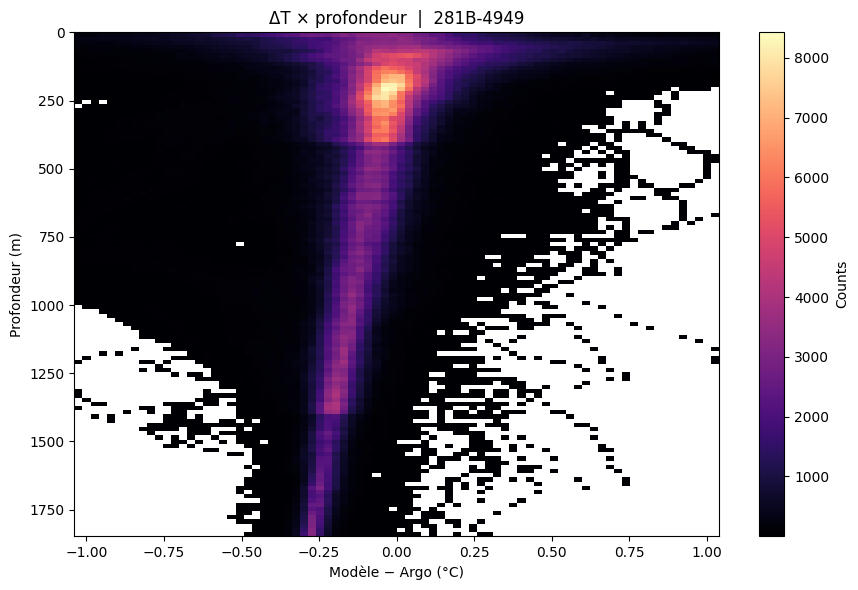

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mask = np.isfinite(all_diff) & np.isfinite(all_pres)
_diff = all_diff[mask]
_pres = all_pres[mask]

dmax_abs   = max(abs(np.nanpercentile(_diff, 1)), abs(np.nanpercentile(_diff, 99)))
pmax       = np.nanpercentile(_pres, 98)
diff_bins  = np.linspace(-dmax_abs, dmax_abs, 81)
depth_bins = np.linspace(0, pmax, 121)

counts, xedges, yedges = np.histogram2d(_diff, _pres, bins=[diff_bins, depth_bins])
counts_masked = np.ma.masked_where(counts == 0, counts)

fig, ax = plt.subplots(figsize=(9, 6))
pcm = ax.pcolormesh(xedges, yedges, counts_masked.T, shading="auto", cmap="magma")
cb  = plt.colorbar(pcm, ax=ax)
cb.set_label("Counts")
ax.invert_yaxis()
ax.set_xlabel("Modèle − Argo (°C)")
ax.set_ylabel("Profondeur (m)")
ax.set_title(f"ΔT × profondeur  |  {tag_name}")
plt.tight_layout()
plt.show()


## 5. Variance profile

In [8]:
import numpy as np
import xarray as xr

bins = np.linspace(0, MAX_DEPTH, 500)
depth_centers = 0.5 * (bins[:-1] + bins[1:])
indices = np.digitize(all_pres, bins)

var_profile = []
for i in range(1, len(bins)):
    diffs = all_diff[indices == i]
    var_profile.append(np.nanvar(diffs) if diffs.size > 3 else np.nan)

var_profile = np.array(var_profile)

# Fill isolated NaN gaps with linear interpolation
from scipy.interpolate import interp1d
valid_mask = np.isfinite(var_profile)
if valid_mask.sum() > 2:
    f_fill = interp1d(
        depth_centers[valid_mask], var_profile[valid_mask],
        bounds_error=False, fill_value=(var_profile[valid_mask][0], var_profile[valid_mask][-1])
    )
    var_profile = f_fill(depth_centers)

print(f"Variance range: {var_profile.min():.4f} – {var_profile.max():.4f} °C²")


Variance range: 0.0012 – 0.9262 °C²


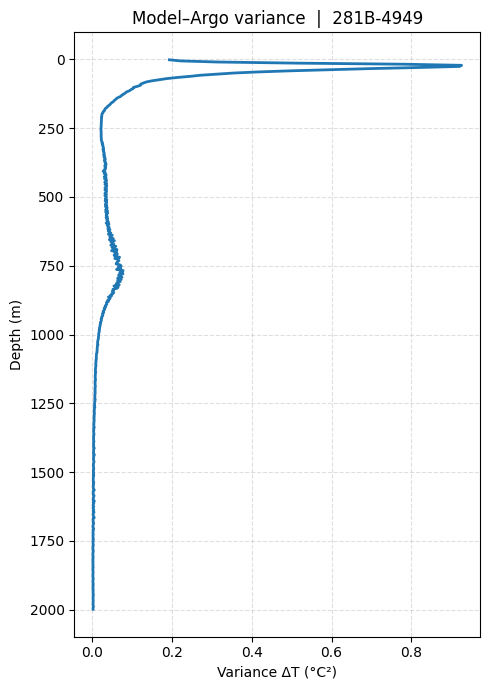

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 7))
plt.plot(var_profile, depth_centers, linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Variance ΔT (°C²)")
plt.ylabel("Depth (m)")
plt.title(f"Model–Argo variance  |  {tag_name}")
plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()


## 6. Save — loaded by Ch2 of the main notebook

In [10]:
import xarray as xr

var_da = xr.DataArray(
    var_profile,
    coords={"depth": depth_centers},
    dims=["depth"],
    name="temperature_variance",
    attrs={"units": "degC^2", "tag_name": tag_name, "max_depth_m": MAX_DEPTH},
)

zarr_path = f"{target_root}/temperature_variance.zarr"
var_da.to_zarr(zarr_path, mode="w", storage_options=storage_options)
print(f"Saved → {zarr_path}")


Saved → s3://gfts-ifremer/tuna/run/capetienne/generic/281B-4949/temperature_variance.zarr


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
